# 03 - Exploratory Data Analysis and Business Insights

This notebook performs exploratory data analysis on the Amsterdam Inside Airbnb market using the cleaned DuckDB warehouse outputs.

The goal is to identify market patterns related to listing supply, room types, pricing, availability, occupancy proxy, host behavior, neighbourhood performance, review scores, and business opportunities.

Each finding includes a business interpretation to make the analysis useful for non-technical stakeholders.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path("..")

WAREHOUSE_PATH = PROJECT_ROOT / "warehouse"
DUCKDB_DATABASE_PATH = WAREHOUSE_PATH / "airbnb_market.duckdb"

FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("DuckDB database exists:", DUCKDB_DATABASE_PATH.exists())
print("Figures path:", FIGURES_PATH)

DuckDB database exists: True
Figures path: ..\reports\figures


In [6]:
conn = duckdb.connect(database=str(DUCKDB_DATABASE_PATH))

print("Connected to DuckDB successfully.")

Connected to DuckDB successfully.


In [7]:
conn.execute("""
SHOW TABLES
""").fetchdf()

,name
0,dim_host
1,dim_listing
2,dim_neighbourhood
3,fact_listing_market
4,host_portfolio_summary
5,listing_master_final
6,market_overview
7,neighbourhood_summary
8,review_score_summary
9,room_type_summary


In [8]:
market_overview_df = conn.execute("SELECT * FROM market_overview").fetchdf()
room_type_summary_df = conn.execute("SELECT * FROM room_type_summary").fetchdf()
neighbourhood_summary_df = conn.execute("SELECT * FROM neighbourhood_summary").fetchdf()
host_portfolio_summary_df = conn.execute("SELECT * FROM host_portfolio_summary").fetchdf()
review_score_summary_df = conn.execute("SELECT * FROM review_score_summary").fetchdf()

listing_master_df = conn.execute("SELECT * FROM listing_master_final").fetchdf()

print("market_overview:", market_overview_df.shape)
print("room_type_summary:", room_type_summary_df.shape)
print("neighbourhood_summary:", neighbourhood_summary_df.shape)
print("host_portfolio_summary:", host_portfolio_summary_df.shape)
print("review_score_summary:", review_score_summary_df.shape)
print("listing_master_final:", listing_master_df.shape)

market_overview: (1, 14)
room_type_summary: (4, 12)
neighbourhood_summary: (22, 13)
host_portfolio_summary: (5, 11)
review_score_summary: (5, 10)
listing_master_final: (10465, 101)


## 1. Market Overview

This section summarizes the overall Amsterdam Airbnb market using listing counts, host counts, neighbourhood coverage, pricing, availability, review activity, and revenue proxy metrics.

In [9]:
market_overview_df.T

,0
total_listings,1.046500e+04
total_known_hosts,9.104000e+03
total_neighbourhoods,2.200000e+01
avg_listing_price,3.442400e+02
median_listing_price,2.870000e+02
avg_availability_rate,2.615000e-01
avg_occupancy_proxy,7.385000e-01
listings_with_reviews,9.432000e+03
listings_without_reviews,1.033000e+03
total_detailed_reviews,5.451620e+05


### Business Interpretation

The Amsterdam Airbnb dataset contains 10,465 listings across 22 neighbourhoods.  
The market has strong review coverage, with most listings having at least one review.

The average occupancy proxy is higher than the average availability rate, suggesting that many listings are unavailable for a large portion of the calendar year.  
However, this should be interpreted carefully because unavailable dates may include both booked nights and host-blocked dates.

The revenue proxy is useful for comparing segments but should not be treated as actual revenue because the calendar dataset does not include daily price fields.

## 2. Room Type Analysis

This section compares Airbnb listing supply, pricing, availability, occupancy proxy, review scores, and revenue proxy by room type.

In [10]:
room_type_summary_df

,room_type,listing_count,market_share_percentage,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,Entire home/apt,8489,81.12,394.62,331.0,0.2133,0.7867,4.87,221489.0,407899491.0,85495.60,3718.0
1,Private room,1929,18.43,203.67,171.0,0.4612,0.5388,4.77,311510.0,55409327.0,33520.46,276.0
2,Hotel room,26,0.25,249.85,227.5,0.7564,0.2436,4.78,6169.0,623504.0,23980.92,0.0
3,Shared room,21,0.20,80.10,52.0,0.7769,0.2231,4.52,5994.0,242392.0,11542.48,0.0


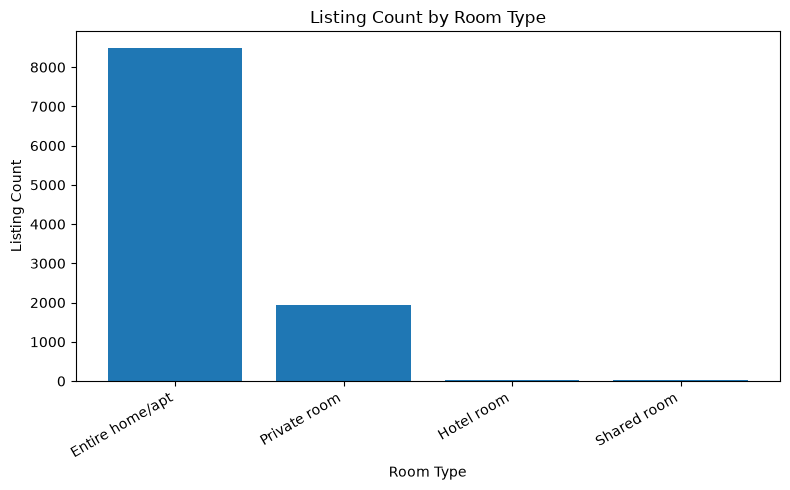

Saved figure to: ..\reports\figures\listing_count_by_room_type.png


In [11]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["listing_count"])
plt.title("Listing Count by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Listing Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "listing_count_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

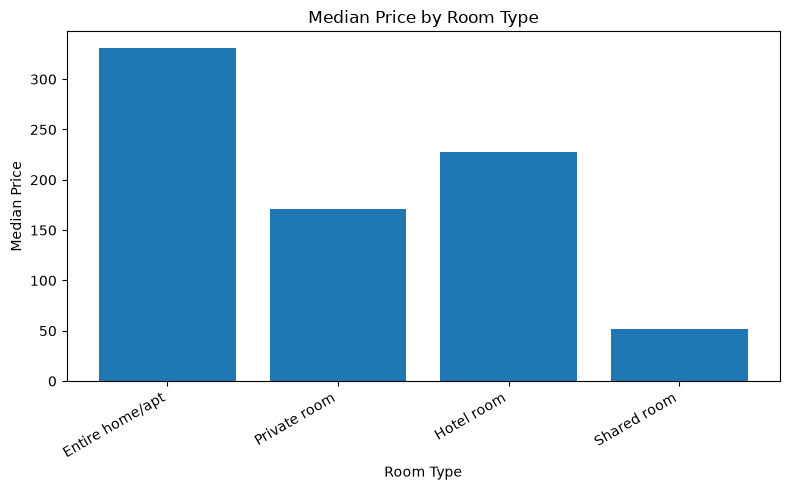

Saved figure to: ..\reports\figures\median_price_by_room_type.png


In [12]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["median_price"])
plt.title("Median Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Median Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "median_price_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

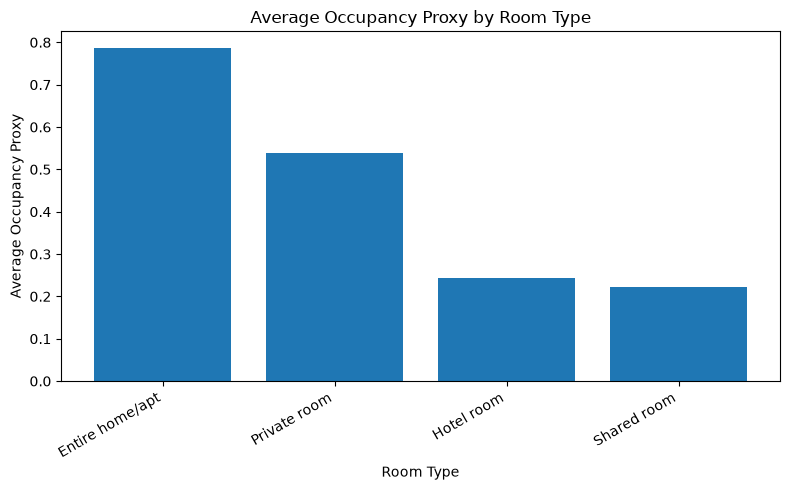

Saved figure to: ..\reports\figures\occupancy_proxy_by_room_type.png


In [13]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_summary_df["room_type"], room_type_summary_df["avg_occupancy_proxy"])
plt.title("Average Occupancy Proxy by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Occupancy Proxy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "occupancy_proxy_by_room_type.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Entire home/apartment listings dominate the Amsterdam Airbnb market by listing count and market share.  
They also show higher median pricing and a stronger occupancy proxy compared with private rooms.

This suggests that entire-home listings are the core commercial segment of the Amsterdam short-term rental market.  
Private rooms appear to be a lower-priced segment with higher availability, which may indicate weaker demand or different host usage patterns.

Hotel rooms and shared rooms have very small listing counts, so their metrics should be interpreted cautiously.

## 3. Neighbourhood Analysis

This section analyzes Airbnb market patterns across Amsterdam neighbourhoods.

The analysis focuses on listing supply, median price, occupancy proxy, review scores, and estimated revenue proxy by neighbourhood.

In [14]:
neighbourhood_summary_df.head(10)

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
1,Centrum-West,1217,923,398.36,290.0,0.3376,0.6624,4.82,116784.0,95.96,65092219.0,74221.46,340.0
2,De Pijp - Rivierenbuurt,1201,1113,380.78,333.5,0.2522,0.7478,4.86,47109.0,39.22,53207727.0,75794.48,499.0
3,Centrum-Oost,933,708,350.41,282.5,0.3600,0.6400,4.81,85025.0,91.13,44237061.0,65246.40,255.0
4,Zuid,709,649,401.85,327.0,0.2984,0.7016,4.88,28645.0,40.40,35151047.0,78113.44,259.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0
7,Oud-Noord,479,428,357.02,266.0,0.2248,0.7752,4.85,25295.0,52.81,19369930.0,68444.98,196.0
8,Bos en Lommer,546,527,281.79,265.0,0.1675,0.8325,4.87,17223.0,31.54,17675443.0,68776.04,289.0
9,Oostelijk Havengebied - Indische Buurt,411,391,290.24,262.0,0.2123,0.7877,4.86,16186.0,39.38,14748957.0,63848.30,180.0


In [15]:
top_neighbourhoods_by_supply = (
    neighbourhood_summary_df
    .sort_values("listing_count", ascending=False)
    .head(10)
)

top_neighbourhoods_by_supply

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
1,Centrum-West,1217,923,398.36,290.0,0.3376,0.6624,4.82,116784.0,95.96,65092219.0,74221.46,340.0
2,De Pijp - Rivierenbuurt,1201,1113,380.78,333.5,0.2522,0.7478,4.86,47109.0,39.22,53207727.0,75794.48,499.0
3,Centrum-Oost,933,708,350.41,282.5,0.3600,0.6400,4.81,85025.0,91.13,44237061.0,65246.40,255.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
4,Zuid,709,649,401.85,327.0,0.2984,0.7016,4.88,28645.0,40.40,35151047.0,78113.44,259.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0
8,Bos en Lommer,546,527,281.79,265.0,0.1675,0.8325,4.87,17223.0,31.54,17675443.0,68776.04,289.0
7,Oud-Noord,479,428,357.02,266.0,0.2248,0.7752,4.85,25295.0,52.81,19369930.0,68444.98,196.0
9,Oostelijk Havengebied - Indische Buurt,411,391,290.24,262.0,0.2123,0.7877,4.86,16186.0,39.38,14748957.0,63848.30,180.0


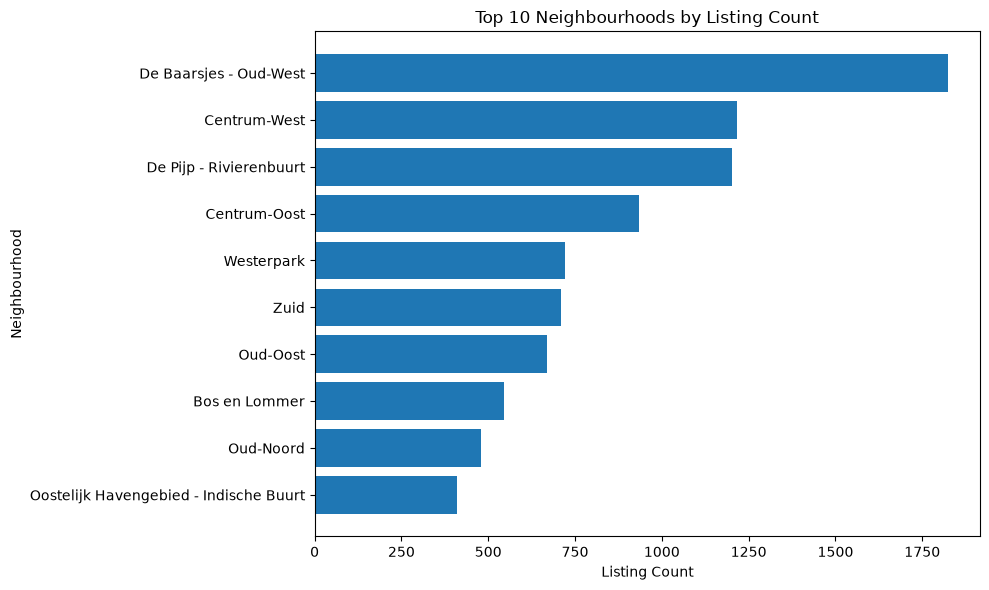

Saved figure to: ..\reports\figures\top_10_neighbourhoods_by_listing_count.png


In [16]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_by_supply["neighbourhood"],
    top_neighbourhoods_by_supply["listing_count"]
)
plt.title("Top 10 Neighbourhoods by Listing Count")
plt.xlabel("Listing Count")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "top_10_neighbourhoods_by_listing_count.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

A small number of neighbourhoods account for a large share of Airbnb supply in Amsterdam.  
High-supply neighbourhoods may represent mature short-term rental zones with strong tourism demand, high host participation, or attractive location characteristics.

For platform operators and market analysts, these areas should be monitored closely because changes in regulation, demand, or host behavior could have a large impact on the overall market.

In [17]:
top_neighbourhoods_by_price = (
    neighbourhood_summary_df
    .dropna(subset=["median_price"])
    .sort_values("median_price", ascending=False)
    .head(10)
)

top_neighbourhoods_by_price

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
2,De Pijp - Rivierenbuurt,1201,1113,380.78,333.5,0.2522,0.7478,4.86,47109.0,39.22,53207727.0,75794.48,499.0
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
4,Zuid,709,649,401.85,327.0,0.2984,0.7016,4.88,28645.0,40.40,35151047.0,78113.44,259.0
1,Centrum-West,1217,923,398.36,290.0,0.3376,0.6624,4.82,116784.0,95.96,65092219.0,74221.46,340.0
12,IJburg - Zeeburgereiland,187,174,330.72,287.0,0.2342,0.7658,4.85,8494.0,45.42,8675081.0,74785.18,71.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
3,Centrum-Oost,933,708,350.41,282.5,0.3600,0.6400,4.81,85025.0,91.13,44237061.0,65246.40,255.0
11,Watergraafsmeer,304,272,311.24,280.0,0.2552,0.7448,4.86,10560.0,34.74,13291645.0,71460.46,118.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0
13,Noord-Oost,179,154,288.65,266.5,0.2646,0.7354,4.87,7073.0,39.51,8353883.0,67370.02,55.0


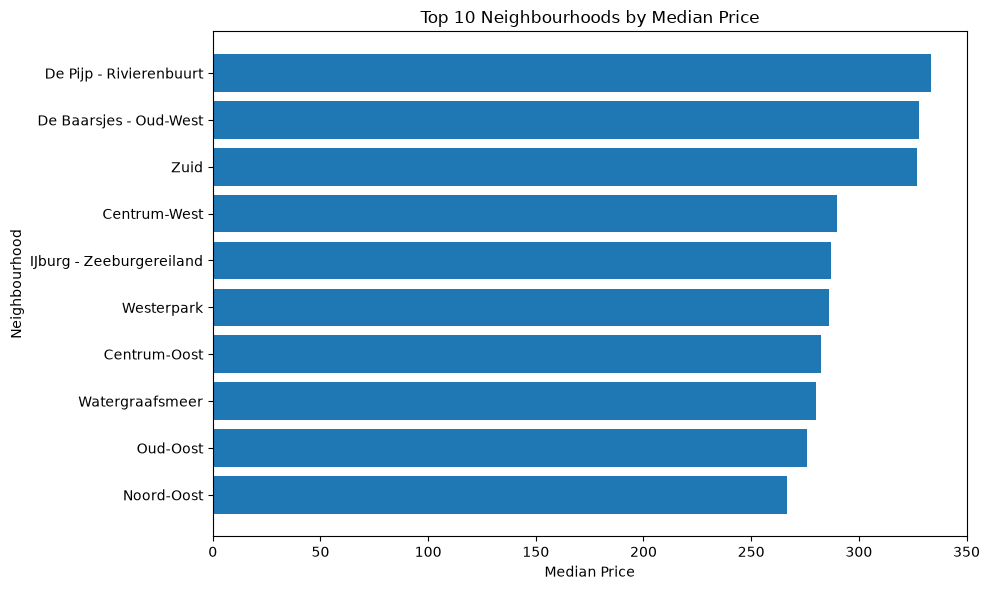

Saved figure to: ..\reports\figures\top_10_neighbourhoods_by_median_price.png


In [18]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_by_price["neighbourhood"],
    top_neighbourhoods_by_price["median_price"]
)
plt.title("Top 10 Neighbourhoods by Median Price")
plt.xlabel("Median Price")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "top_10_neighbourhoods_by_median_price.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Neighbourhoods with higher median prices may represent premium locations, stronger tourism appeal, better accessibility, or more desirable property types.

Price differences across neighbourhoods can help hosts benchmark pricing strategies and help investors identify high-value market areas.  
However, pricing should be interpreted together with occupancy proxy, review scores, and listing count because high price alone does not always indicate strong performance.

In [19]:
top_neighbourhoods_by_occupancy = (
    neighbourhood_summary_df
    .sort_values("avg_occupancy_proxy", ascending=False)
    .head(10)
)

top_neighbourhoods_by_occupancy

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
8,Bos en Lommer,546,527,281.79,265.0,0.1675,0.8325,4.87,17223.0,31.54,17675443.0,68776.04,289.0
10,Noord-West,312,292,265.23,259.0,0.2008,0.7992,4.87,10339.0,33.14,14127902.0,68916.60,107.0
9,Oostelijk Havengebied - Indische Buurt,411,391,290.24,262.0,0.2123,0.7877,4.86,16186.0,39.38,14748957.0,63848.30,180.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
21,Bijlmer-Oost,39,33,206.67,120.5,0.2225,0.7775,4.79,1646.0,42.21,1153954.0,48081.42,15.0
7,Oud-Noord,479,428,357.02,266.0,0.2248,0.7752,4.85,25295.0,52.81,19369930.0,68444.98,196.0
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
14,Slotervaart,223,196,253.38,233.0,0.2283,0.7717,4.87,10228.0,45.87,6851824.0,56626.64,102.0
12,IJburg - Zeeburgereiland,187,174,330.72,287.0,0.2342,0.7658,4.85,8494.0,45.42,8675081.0,74785.18,71.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0


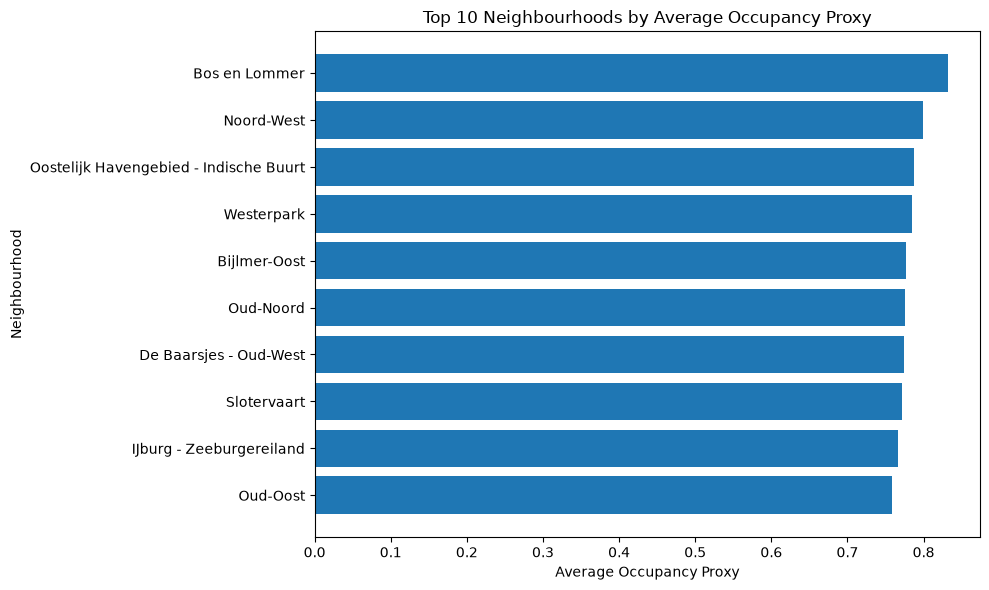

Saved figure to: ..\reports\figures\top_10_neighbourhoods_by_occupancy_proxy.png


In [20]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_by_occupancy["neighbourhood"],
    top_neighbourhoods_by_occupancy["avg_occupancy_proxy"]
)
plt.title("Top 10 Neighbourhoods by Average Occupancy Proxy")
plt.xlabel("Average Occupancy Proxy")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "top_10_neighbourhoods_by_occupancy_proxy.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Neighbourhoods with higher occupancy proxy have lower availability across the calendar year.  
This may indicate stronger demand, more frequent bookings, or hosts blocking dates for reasons outside guest demand.

Because unavailable dates are not confirmed bookings, this metric should be interpreted as a demand proxy rather than actual occupancy.

In [21]:
top_neighbourhoods_by_revenue_proxy = (
    neighbourhood_summary_df
    .sort_values("total_revenue_proxy", ascending=False)
    .head(10)
)

top_neighbourhoods_by_revenue_proxy

,neighbourhood,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy,listings_missing_price
0,De Baarsjes - Oud-West,1825,1710,364.68,328.0,0.2261,0.7739,4.87,69085.0,37.85,88390081.0,82376.59,752.0
1,Centrum-West,1217,923,398.36,290.0,0.3376,0.6624,4.82,116784.0,95.96,65092219.0,74221.46,340.0
2,De Pijp - Rivierenbuurt,1201,1113,380.78,333.5,0.2522,0.7478,4.86,47109.0,39.22,53207727.0,75794.48,499.0
3,Centrum-Oost,933,708,350.41,282.5,0.3600,0.6400,4.81,85025.0,91.13,44237061.0,65246.40,255.0
4,Zuid,709,649,401.85,327.0,0.2984,0.7016,4.88,28645.0,40.40,35151047.0,78113.44,259.0
5,Westerpark,720,680,332.57,286.0,0.2152,0.7848,4.87,27910.0,38.76,30809751.0,76073.46,315.0
6,Oud-Oost,670,598,308.24,276.0,0.2418,0.7582,4.86,25575.0,38.17,25874801.0,66687.63,282.0
7,Oud-Noord,479,428,357.02,266.0,0.2248,0.7752,4.85,25295.0,52.81,19369930.0,68444.98,196.0
8,Bos en Lommer,546,527,281.79,265.0,0.1675,0.8325,4.87,17223.0,31.54,17675443.0,68776.04,289.0
9,Oostelijk Havengebied - Indische Buurt,411,391,290.24,262.0,0.2123,0.7877,4.86,16186.0,39.38,14748957.0,63848.30,180.0


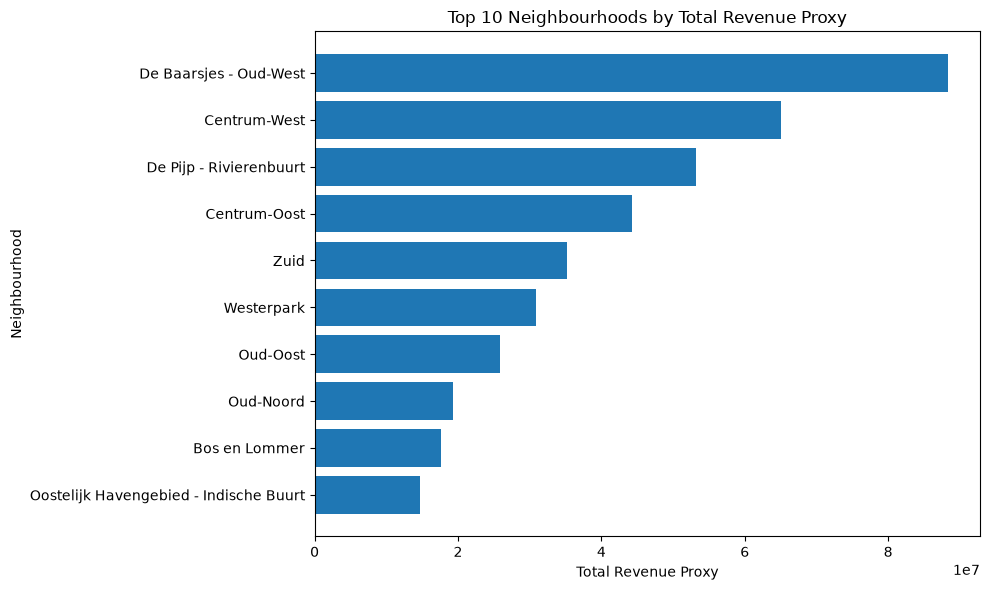

Saved figure to: ..\reports\figures\top_10_neighbourhoods_by_revenue_proxy.png


In [22]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_neighbourhoods_by_revenue_proxy["neighbourhood"],
    top_neighbourhoods_by_revenue_proxy["total_revenue_proxy"]
)
plt.title("Top 10 Neighbourhoods by Total Revenue Proxy")
plt.xlabel("Total Revenue Proxy")
plt.ylabel("Neighbourhood")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "top_10_neighbourhoods_by_revenue_proxy.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Neighbourhoods with high total revenue proxy usually combine three factors: high listing supply, higher prices, and strong occupancy proxy.

This metric is useful for comparing relative market strength across neighbourhoods, but it should not be treated as actual revenue because it is estimated using listing-level price and unavailable calendar days.

## 4. Host Portfolio Analysis

This section analyzes Airbnb listings by host portfolio segment.

Host portfolio segmentation helps identify whether the market is mostly driven by single-listing hosts, small portfolio hosts, or larger professional-style operators.

In [23]:
host_portfolio_summary_df

,host_portfolio_segment,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,total_revenue_proxy,avg_revenue_proxy
0,Single-listing host,8509,8509,371.11,318.0,0.2085,0.7915,4.88,334320.0,396232619.0,82359.72
1,Small portfolio host,1309,537,274.87,202.0,0.4396,0.5604,4.76,161660.0,47775711.0,45113.99
2,Medium portfolio host,483,55,276.40,209.0,0.5640,0.4360,4.65,34771.0,17365435.0,39377.40
3,Unknown Host,96,0,177.53,141.0,0.7595,0.2405,NaN,9048.0,1314652.0,13985.66
4,Large portfolio host,68,3,189.39,151.0,0.6113,0.3887,4.54,5363.0,1486297.0,22519.65


In [24]:
host_portfolio_chart_df = (
    host_portfolio_summary_df
    .sort_values("listing_count", ascending=False)
    .copy()
)

host_portfolio_chart_df

,host_portfolio_segment,listing_count,known_host_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,avg_review_score,total_reviews,total_revenue_proxy,avg_revenue_proxy
0,Single-listing host,8509,8509,371.11,318.0,0.2085,0.7915,4.88,334320.0,396232619.0,82359.72
1,Small portfolio host,1309,537,274.87,202.0,0.4396,0.5604,4.76,161660.0,47775711.0,45113.99
2,Medium portfolio host,483,55,276.40,209.0,0.5640,0.4360,4.65,34771.0,17365435.0,39377.40
3,Unknown Host,96,0,177.53,141.0,0.7595,0.2405,NaN,9048.0,1314652.0,13985.66
4,Large portfolio host,68,3,189.39,151.0,0.6113,0.3887,4.54,5363.0,1486297.0,22519.65


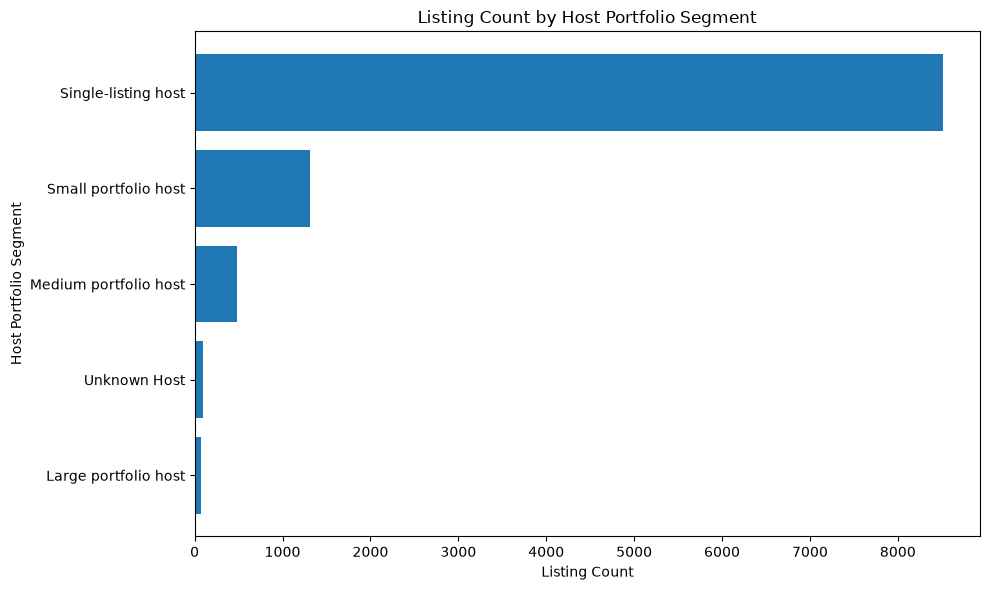

Saved figure to: ..\reports\figures\listing_count_by_host_portfolio_segment.png


In [25]:
plt.figure(figsize=(10, 6))
plt.barh(
    host_portfolio_chart_df["host_portfolio_segment"],
    host_portfolio_chart_df["listing_count"]
)
plt.title("Listing Count by Host Portfolio Segment")
plt.xlabel("Listing Count")
plt.ylabel("Host Portfolio Segment")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "listing_count_by_host_portfolio_segment.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Single-listing hosts account for the largest share of Airbnb listings in the Amsterdam dataset.  
This suggests that the market is strongly driven by individual or casual hosts rather than only large professional operators.

However, small and medium portfolio hosts still represent an important commercial segment because they manage multiple listings and may use more structured pricing and availability strategies.

The Unknown Host segment represents records with missing host information and should be treated as a data quality category rather than a real host segment.

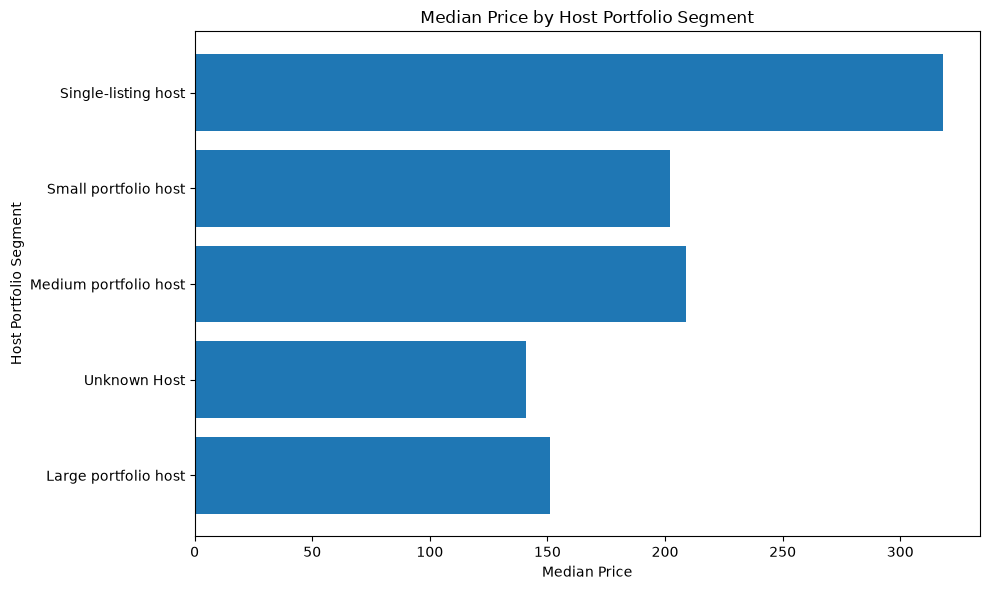

Saved figure to: ..\reports\figures\median_price_by_host_portfolio_segment.png


In [26]:
plt.figure(figsize=(10, 6))
plt.barh(
    host_portfolio_chart_df["host_portfolio_segment"],
    host_portfolio_chart_df["median_price"]
)
plt.title("Median Price by Host Portfolio Segment")
plt.xlabel("Median Price")
plt.ylabel("Host Portfolio Segment")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "median_price_by_host_portfolio_segment.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Median price varies across host portfolio segments.  
Single-listing hosts show higher median pricing than larger portfolio segments in this dataset.

This may indicate that single-listing hosts are offering more differentiated or premium homes, while larger portfolio operators may manage more standardized or lower-priced inventory.  
This should be investigated further with property type and neighbourhood context before making a final conclusion.

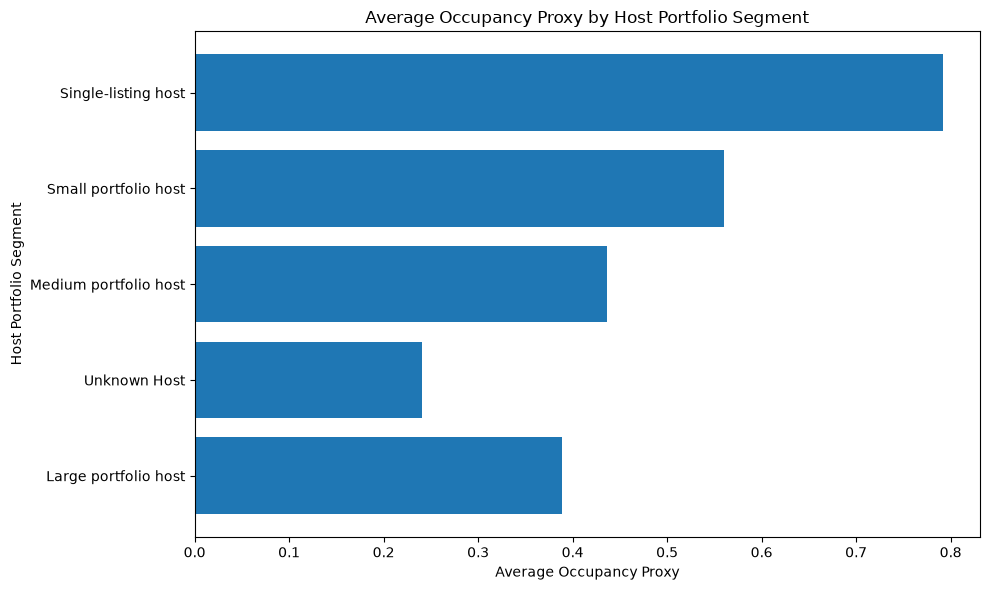

Saved figure to: ..\reports\figures\occupancy_proxy_by_host_portfolio_segment.png


In [27]:
plt.figure(figsize=(10, 6))
plt.barh(
    host_portfolio_chart_df["host_portfolio_segment"],
    host_portfolio_chart_df["avg_occupancy_proxy"]
)
plt.title("Average Occupancy Proxy by Host Portfolio Segment")
plt.xlabel("Average Occupancy Proxy")
plt.ylabel("Host Portfolio Segment")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "occupancy_proxy_by_host_portfolio_segment.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Single-listing hosts show a high occupancy proxy compared with larger portfolio segments.  
This may indicate stronger demand, lower availability, or hosts blocking more calendar days.

Because occupancy proxy is based on unavailable days, it should be interpreted carefully and not treated as confirmed booking occupancy.

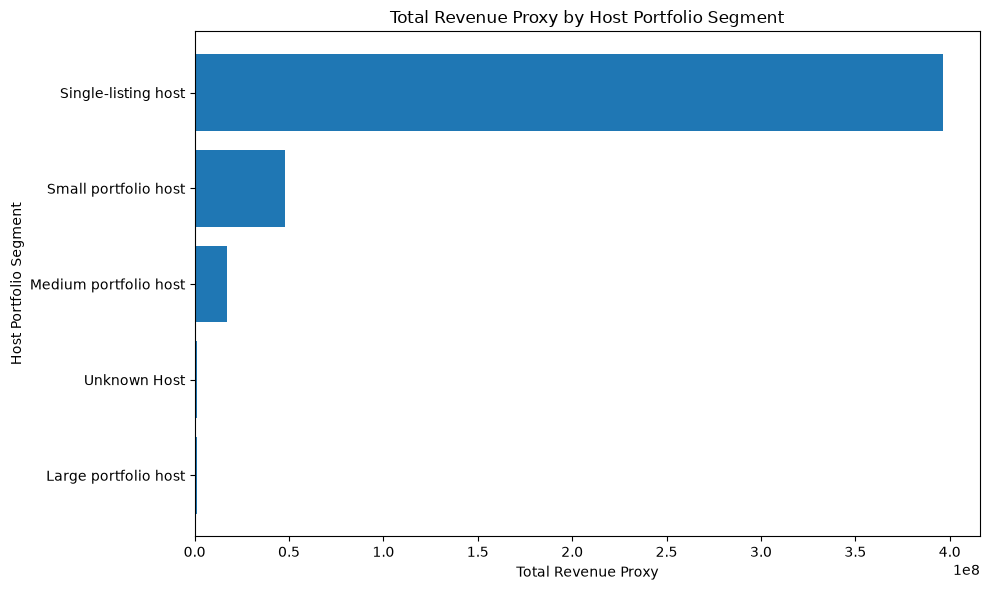

Saved figure to: ..\reports\figures\revenue_proxy_by_host_portfolio_segment.png


In [28]:
plt.figure(figsize=(10, 6))
plt.barh(
    host_portfolio_chart_df["host_portfolio_segment"],
    host_portfolio_chart_df["total_revenue_proxy"]
)
plt.title("Total Revenue Proxy by Host Portfolio Segment")
plt.xlabel("Total Revenue Proxy")
plt.ylabel("Host Portfolio Segment")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = FIGURES_PATH / "revenue_proxy_by_host_portfolio_segment.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Single-listing hosts generate the largest total revenue proxy mainly because they represent the largest listing segment.

This does not mean every single-listing host earns more individually.  
For individual performance, average revenue proxy should be considered together with listing count, price availability, neighbourhood, and occupancy proxy.

## 5. Review Score Analysis

This section analyzes listing performance by review score band.

Review score bands help compare pricing, availability, occupancy proxy, review activity, and revenue proxy across different guest satisfaction levels.

In [29]:
review_score_summary_df

,review_score_band,listing_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy
0,Excellent,7047,356.29,309.0,0.2211,0.7789,345884.0,49.08,336075338.0,79960.82
1,Very good,1794,292.38,241.0,0.3018,0.6982,171054.0,95.35,67916253.0,57899.62
2,No rating,1119,389.79,286.0,0.3778,0.6222,9048.0,8.09,45524688.0,62277.27
3,Good,434,250.67,204.0,0.4136,0.5864,18741.0,43.18,12897782.0,41206.97
4,Below 4.0,71,465.57,212.0,0.4886,0.5114,435.0,6.13,1760653.0,34522.61


In [30]:
review_score_order = [
    "Excellent",
    "Very good",
    "Good",
    "Below 4.0",
    "No rating"
]

review_score_chart_df = review_score_summary_df.copy()

review_score_chart_df["review_score_band"] = pd.Categorical(
    review_score_chart_df["review_score_band"],
    categories=review_score_order,
    ordered=True
)

review_score_chart_df = review_score_chart_df.sort_values("review_score_band")

review_score_chart_df

,review_score_band,listing_count,avg_price,median_price,avg_availability_rate,avg_occupancy_proxy,total_reviews,avg_reviews_per_listing,total_revenue_proxy,avg_revenue_proxy
0,Excellent,7047,356.29,309.0,0.2211,0.7789,345884.0,49.08,336075338.0,79960.82
1,Very good,1794,292.38,241.0,0.3018,0.6982,171054.0,95.35,67916253.0,57899.62
3,Good,434,250.67,204.0,0.4136,0.5864,18741.0,43.18,12897782.0,41206.97
4,Below 4.0,71,465.57,212.0,0.4886,0.5114,435.0,6.13,1760653.0,34522.61
2,No rating,1119,389.79,286.0,0.3778,0.6222,9048.0,8.09,45524688.0,62277.27


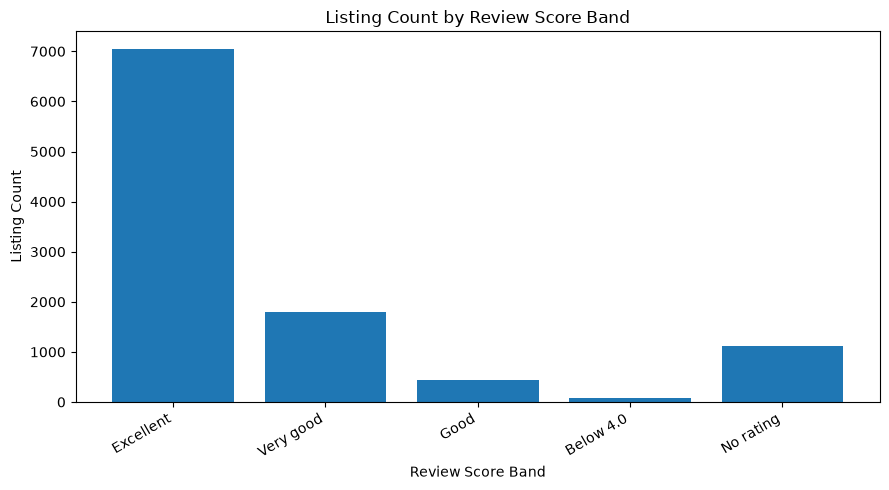

Saved figure to: ..\reports\figures\listing_count_by_review_score_band.png


In [31]:
plt.figure(figsize=(9, 5))
plt.bar(
    review_score_chart_df["review_score_band"].astype(str),
    review_score_chart_df["listing_count"]
)
plt.title("Listing Count by Review Score Band")
plt.xlabel("Review Score Band")
plt.ylabel("Listing Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "listing_count_by_review_score_band.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Most rated listings fall into the Excellent category.  
This suggests that the Amsterdam Airbnb market has generally high review scores, which may reflect strong guest satisfaction or possible rating inflation.

The No rating group is also important because it represents listings without enough review history. These listings may be new, inactive, or less frequently booked.

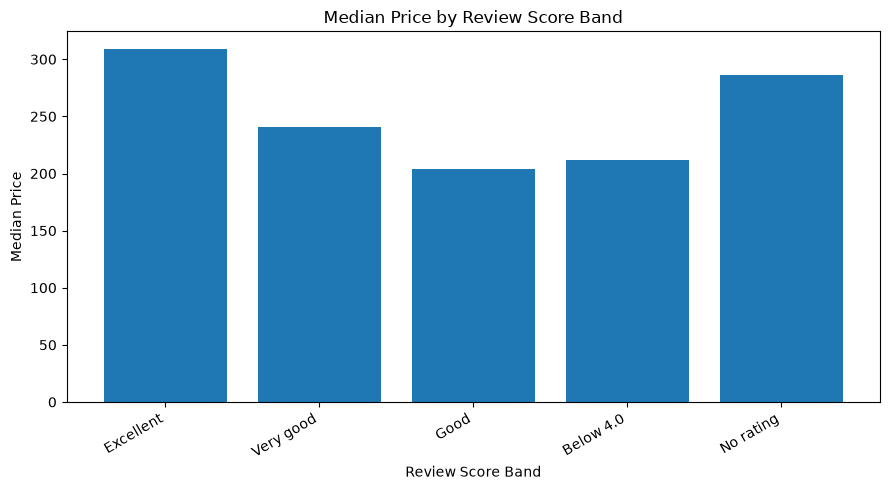

Saved figure to: ..\reports\figures\median_price_by_review_score_band.png


In [32]:
plt.figure(figsize=(9, 5))
plt.bar(
    review_score_chart_df["review_score_band"].astype(str),
    review_score_chart_df["median_price"]
)
plt.title("Median Price by Review Score Band")
plt.xlabel("Review Score Band")
plt.ylabel("Median Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "median_price_by_review_score_band.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Median price differs across review score bands, but price should not be interpreted using review score alone.  
Higher or lower prices may also be influenced by room type, neighbourhood, property size, and availability strategy.

The No rating group should be interpreted carefully because missing ratings may indicate new listings or listings without enough guest feedback.

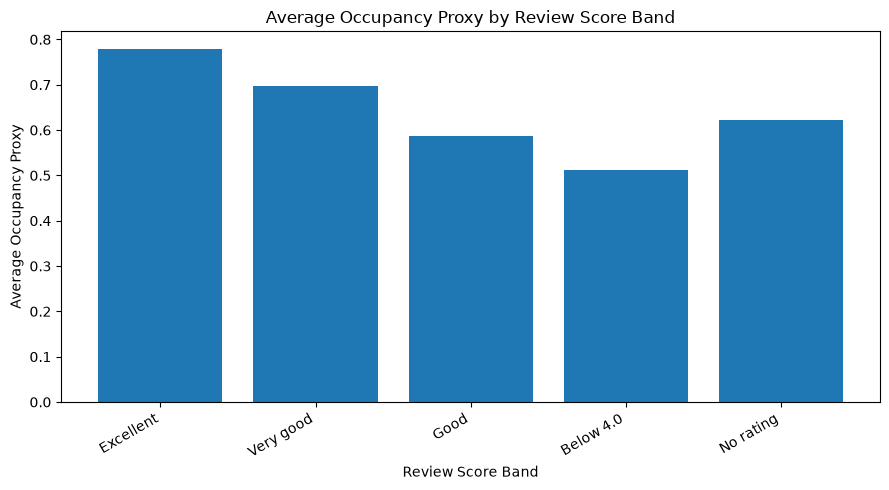

Saved figure to: ..\reports\figures\occupancy_proxy_by_review_score_band.png


In [33]:
plt.figure(figsize=(9, 5))
plt.bar(
    review_score_chart_df["review_score_band"].astype(str),
    review_score_chart_df["avg_occupancy_proxy"]
)
plt.title("Average Occupancy Proxy by Review Score Band")
plt.xlabel("Review Score Band")
plt.ylabel("Average Occupancy Proxy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "occupancy_proxy_by_review_score_band.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

Listings with stronger review score bands show different occupancy proxy patterns.  
This may indicate that guest satisfaction is related to booking demand, but the relationship should be tested statistically before making a final conclusion.

Because occupancy proxy is based on unavailable calendar days, it should be interpreted as a demand signal rather than confirmed occupancy.

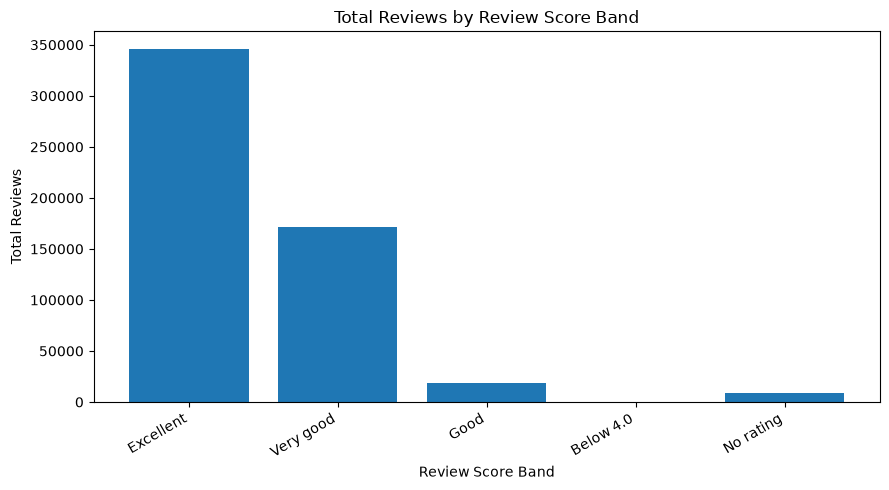

Saved figure to: ..\reports\figures\total_reviews_by_review_score_band.png


In [34]:
plt.figure(figsize=(9, 5))
plt.bar(
    review_score_chart_df["review_score_band"].astype(str),
    review_score_chart_df["total_reviews"]
)
plt.title("Total Reviews by Review Score Band")
plt.xlabel("Review Score Band")
plt.ylabel("Total Reviews")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "total_reviews_by_review_score_band.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

The Excellent review score band contributes the largest share of total review volume.  
This suggests that many high-rated listings also have meaningful guest activity.

However, review volume and review score should be analyzed together because a listing with many reviews and a high score is usually more reliable than a listing with a high score but very few reviews.

### Review Score Analysis Summary

The review score analysis shows that the Amsterdam Airbnb market is heavily concentrated in high review score bands.  
Excellent-rated listings dominate both listing count and review volume.

This pattern may indicate strong guest satisfaction, but it may also suggest review score inflation because very high ratings are common across the platform.  
Further statistical analysis is needed to test whether review score differences are meaningfully related to price, occupancy proxy, or revenue proxy.

## 6. Price Distribution and Outlier Analysis

This section analyzes the distribution of listing prices and identifies potential price outliers.

Price is one of the most important variables for market analysis, statistical testing, and machine learning.  
Before using price in deeper analysis, it is important to understand missing values, skewness, extreme values, and segment-level differences.

In [35]:
price_analysis_df = listing_master_df[
    listing_master_df["price_numeric"].notna() &
    (listing_master_df["price_numeric"] > 0)
].copy()

print("Total listings:", len(listing_master_df))
print("Listings with valid positive price:", len(price_analysis_df))
print("Listings missing or invalid price:", len(listing_master_df) - len(price_analysis_df))

Total listings: 10465
Listings with valid positive price: 6471
Listings missing or invalid price: 3994


In [36]:
price_summary = price_analysis_df["price_numeric"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

price_summary

count     6471.000000
mean       344.241385
std        326.010862
min         15.000000
25%        205.000000
50%        287.000000
75%        410.000000
90%        580.000000
95%        727.500000
99%       1145.300000
max      11412.000000
Name: price_numeric, dtype: float64

In [37]:
price_summary_df = price_summary.reset_index()
price_summary_df.columns = ["metric", "value"]

price_summary_output_path = PROJECT_ROOT / "reports" / "analytics_outputs" / "price_summary_statistics.csv"
price_summary_df.to_csv(price_summary_output_path, index=False)

print(f"Price summary saved to: {price_summary_output_path}")

Price summary saved to: ..\reports\analytics_outputs\price_summary_statistics.csv


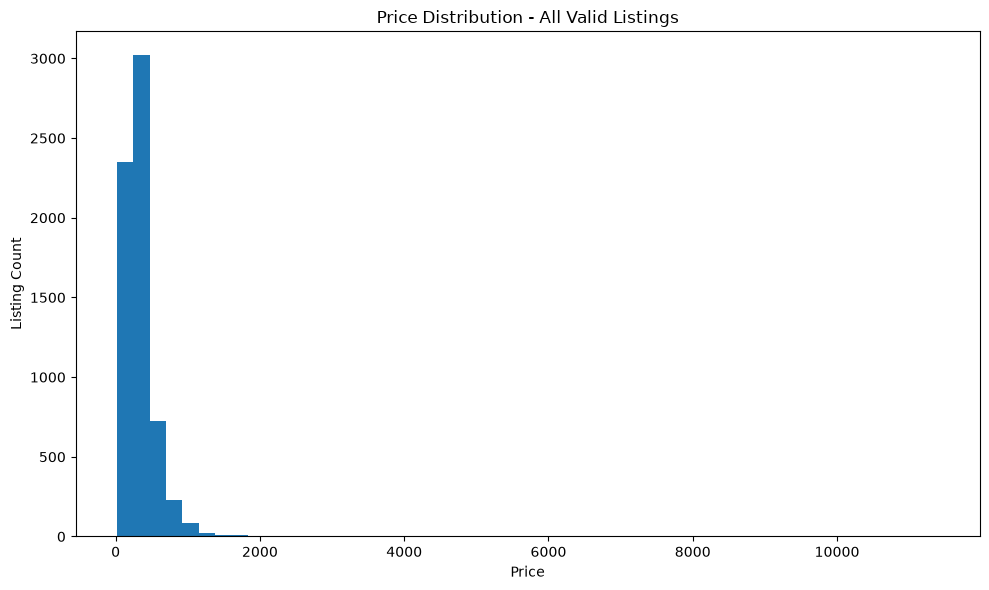

Saved figure to: ..\reports\figures\price_distribution_all_valid_listings.png


In [38]:
plt.figure(figsize=(10, 6))
plt.hist(price_analysis_df["price_numeric"], bins=50)
plt.title("Price Distribution - All Valid Listings")
plt.xlabel("Price")
plt.ylabel("Listing Count")
plt.tight_layout()

output_path = FIGURES_PATH / "price_distribution_all_valid_listings.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

The full price distribution shows whether the Amsterdam Airbnb market contains extreme high-price listings.  
If the distribution is strongly right-skewed, the mean price may be pulled upward by expensive outliers.

For business reporting, median price may be more reliable than average price because it better represents a typical listing.

In [39]:
price_99th_percentile = price_analysis_df["price_numeric"].quantile(0.99)

price_capped_99_df = price_analysis_df[
    price_analysis_df["price_numeric"] <= price_99th_percentile
].copy()

print("99th percentile price:", price_99th_percentile)
print("Rows after 99th percentile cap:", len(price_capped_99_df))

99th percentile price: 1145.300000000002
Rows after 99th percentile cap: 6406


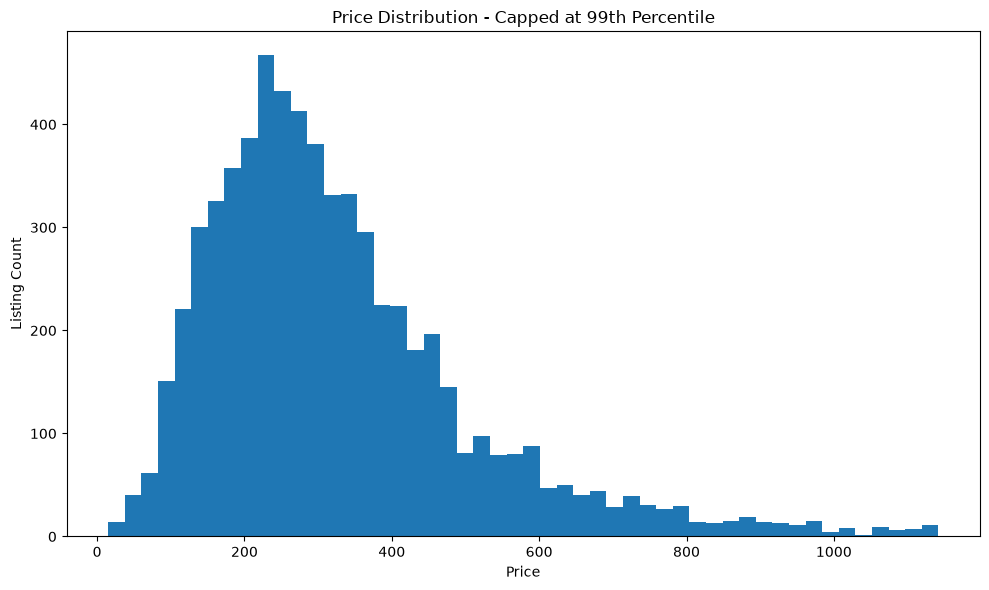

Saved figure to: ..\reports\figures\price_distribution_capped_99th_percentile.png


In [40]:
plt.figure(figsize=(10, 6))
plt.hist(price_capped_99_df["price_numeric"], bins=50)
plt.title("Price Distribution - Capped at 99th Percentile")
plt.xlabel("Price")
plt.ylabel("Listing Count")
plt.tight_layout()

output_path = FIGURES_PATH / "price_distribution_capped_99th_percentile.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

The 99th-percentile-capped distribution provides a clearer view of typical market pricing by reducing the visual effect of extreme luxury or unusual listings.

This chart is useful for understanding the mainstream price range, while the full distribution remains important for documenting outliers.

In [41]:
q1 = price_analysis_df["price_numeric"].quantile(0.25)
q3 = price_analysis_df["price_numeric"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_analysis_df["price_outlier_iqr_flag"] = (
    (price_analysis_df["price_numeric"] < lower_bound) |
    (price_analysis_df["price_numeric"] > upper_bound)
)

outlier_summary = {
    "q1": q1,
    "q3": q3,
    "iqr": iqr,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound,
    "outlier_count": int(price_analysis_df["price_outlier_iqr_flag"].sum()),
    "outlier_percentage": round(price_analysis_df["price_outlier_iqr_flag"].mean() * 100, 2)
}

outlier_summary_df = pd.DataFrame(
    list(outlier_summary.items()),
    columns=["metric", "value"]
)

outlier_summary_df

,metric,value
0,q1,205.00
1,q3,410.00
2,iqr,205.00
3,lower_bound,-102.50
4,upper_bound,717.50
5,outlier_count,346.00
6,outlier_percentage,5.35


In [42]:
outlier_summary_output_path = PROJECT_ROOT / "reports" / "analytics_outputs" / "price_outlier_summary.csv"

outlier_summary_df.to_csv(outlier_summary_output_path, index=False)

print(f"Price outlier summary saved to: {outlier_summary_output_path}")

Price outlier summary saved to: ..\reports\analytics_outputs\price_outlier_summary.csv


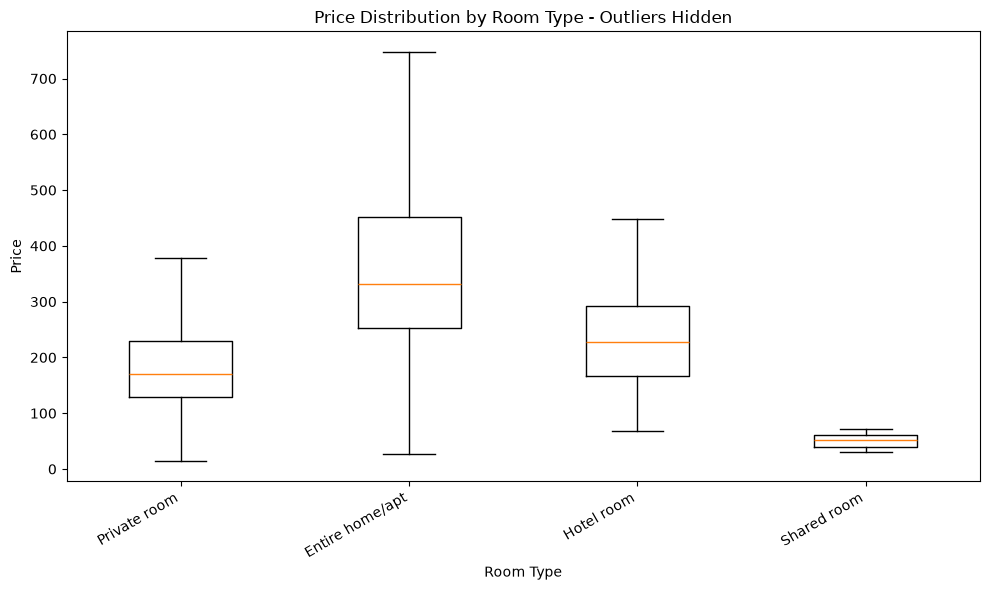

Saved figure to: ..\reports\figures\price_distribution_by_room_type_boxplot.png


In [45]:
plt.close("all")

room_type_price_data = []
room_type_labels = []

for room_type in price_analysis_df["room_type"].dropna().unique():
    room_prices = price_analysis_df[
        price_analysis_df["room_type"] == room_type
    ]["price_numeric"]
    
    room_type_price_data.append(room_prices)
    room_type_labels.append(room_type)

plt.figure(figsize=(10, 6))
plt.boxplot(
    room_type_price_data,
    tick_labels=room_type_labels,
    showfliers=False
)
plt.title("Price Distribution by Room Type - Outliers Hidden")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "price_distribution_by_room_type_boxplot.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

The room-type boxplot compares typical price ranges while hiding extreme outliers for readability.

Entire home/apartment listings generally show higher price levels than private rooms and shared rooms.  
This supports the earlier finding that entire-home listings are the premium and dominant segment in the Amsterdam market.

In [46]:
top_price_outliers = (
    price_analysis_df
    .sort_values("price_numeric", ascending=False)
    [
        [
            "listing_id",
            "listing_name",
            "room_type",
            "neighbourhood",
            "price_numeric",
            "availability_rate",
            "occupancy_proxy",
            "review_scores_rating",
            "detailed_review_count"
        ]
    ]
    .head(20)
)

top_price_outliers

,listing_id,listing_name,room_type,neighbourhood,price_numeric,availability_rate,occupancy_proxy,review_scores_rating,detailed_review_count
373,2474754,pay a little more get a lot more,Entire home/apt,Centrum-West,11412.0,1.0000,0.0000,4.71,24
9594,1548025772403046607,Luxurious familyhome in Amsterdam South,Entire home/apt,De Pijp - Rivierenbuurt,11412.0,0.9041,0.0959,3.00,1
4364,612289973482163299,Enjoy ShipStays in Amsterdam!,Entire home/apt,Oud-Noord,7200.0,0.9808,0.0192,NaN,0
4499,643315499225242586,Enjoy ShipStays in Amsterdam!,Entire home/apt,Oud-Noord,7200.0,0.9808,0.0192,NaN,0
3491,42910448,Appartement centrum Amsterdam,Entire home/apt,Zuid,5706.0,1.0000,0.0000,NaN,0
6267,968203403339639631,Elegant & unique townhouse in famous canal area,Entire home/apt,Centrum-West,3383.0,0.9836,0.0164,NaN,0
10388,1693616534399481978,Unique Art Deco Canal House in Amsterdam Centre,Entire home/apt,Centrum-West,3025.0,0.9918,0.0082,NaN,0
10406,1698438915127575870,Luxe Canal House • Private Garden • 4br • Centre,Entire home/apt,Centrum-West,2700.0,0.2082,0.7918,NaN,0
1502,15304003,Luxury houseboat Amsterdam Centre! (3BR 2BA 11...,Entire home/apt,Centrum-Oost,2477.0,0.9836,0.0164,4.93,27
6350,984625805593041593,Luxurious Penthouse | 360 ° view | Privacy | ADAM,Entire home/apt,Centrum-West,2354.0,0.3315,0.6685,4.87,15


In [47]:
top_price_outliers_output_path = PROJECT_ROOT / "reports" / "analytics_outputs" / "top_price_outliers.csv"

top_price_outliers.to_csv(top_price_outliers_output_path, index=False)

print(f"Top price outliers saved to: {top_price_outliers_output_path}")

Top price outliers saved to: ..\reports\analytics_outputs\top_price_outliers.csv


### Price Distribution Summary

Price analysis shows that listing prices should be treated carefully because short-term rental prices are often right-skewed.  
Extreme high-price listings can distort average price, making median price a more stable measure for business interpretation.

For future statistical analysis and machine learning, price outliers should be handled explicitly.  
Potential strategies include using median-based reporting, applying log transformation, capping extreme prices, or modeling only listings within a reasonable price range.

No price records are removed at this stage. Outliers are only flagged and documented.

## 7. Availability and Occupancy Proxy Analysis

This section analyzes listing availability and occupancy proxy patterns.

The occupancy proxy is calculated from unavailable calendar days.  
It should not be interpreted as confirmed booking occupancy because unavailable dates may include both booked nights and host-blocked dates.

In [48]:
availability_analysis_df = listing_master_df[
    listing_master_df["availability_rate"].notna() &
    listing_master_df["occupancy_proxy"].notna()
].copy()

print("Total listings:", len(listing_master_df))
print("Listings with availability metrics:", len(availability_analysis_df))

Total listings: 10465
Listings with availability metrics: 10465


In [49]:
availability_summary = availability_analysis_df[
    [
        "availability_rate",
        "occupancy_proxy",
        "weekend_availability_rate",
        "weekday_availability_rate"
    ]
].describe()

availability_summary

,availability_rate,occupancy_proxy,weekend_availability_rate,weekday_availability_rate
count,10465.000000,10465.000000,10465.000000,10465.000000
mean,0.261473,0.738527,0.259915,0.262094
std,0.326940,0.326940,0.324469,0.328274
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.517800,0.000000,0.000000
50%,0.071200,0.928800,0.076900,0.072800
75%,0.482200,1.000000,0.480800,0.482800
max,1.000000,1.000000,1.000000,1.000000


In [50]:
availability_summary_output_path = PROJECT_ROOT / "reports" / "analytics_outputs" / "availability_summary_statistics.csv"

availability_summary.to_csv(availability_summary_output_path)

print(f"Availability summary saved to: {availability_summary_output_path}")

Availability summary saved to: ..\reports\analytics_outputs\availability_summary_statistics.csv


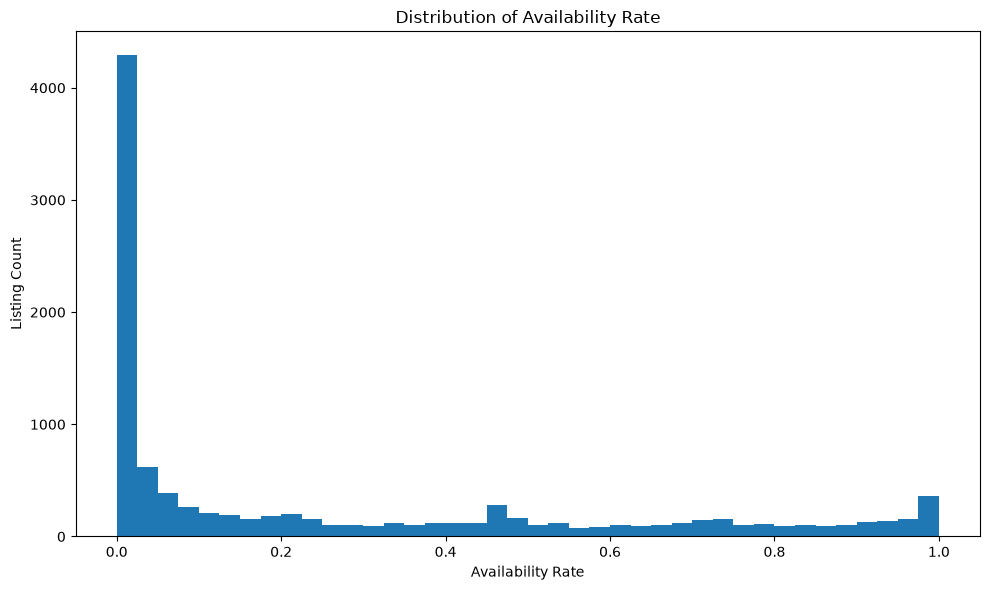

Saved figure to: ..\reports\figures\availability_rate_distribution.png


In [51]:
plt.figure(figsize=(10, 6))
plt.hist(availability_analysis_df["availability_rate"], bins=40)
plt.title("Distribution of Availability Rate")
plt.xlabel("Availability Rate")
plt.ylabel("Listing Count")
plt.tight_layout()

output_path = FIGURES_PATH / "availability_rate_distribution.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

The availability rate distribution shows how often listings are open across the calendar year.  
Listings with low availability may be frequently booked, host-blocked, or used only selectively.

Because unavailable dates are not confirmed bookings, this pattern should be interpreted as market availability behavior rather than exact demand.

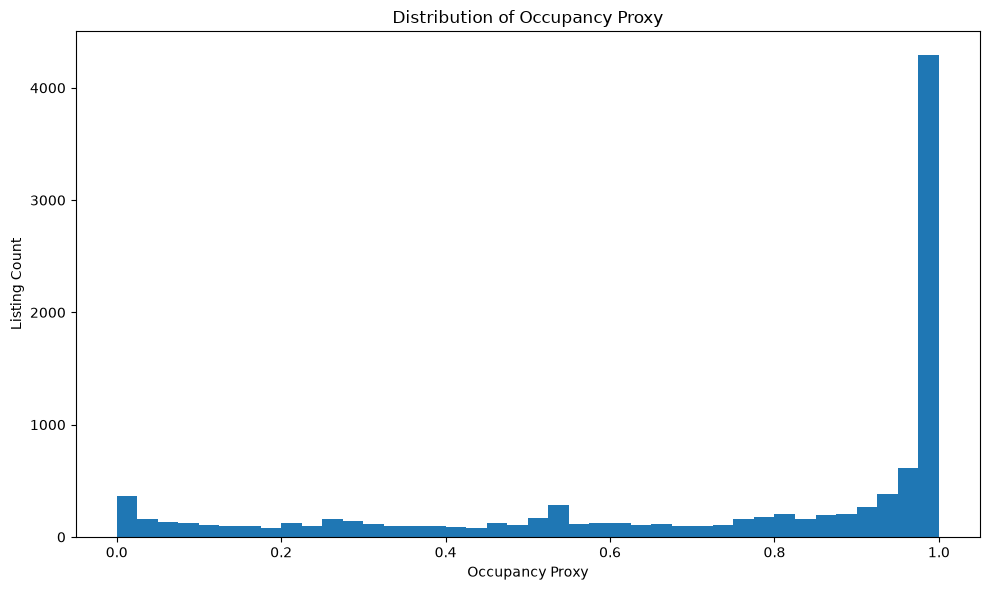

Saved figure to: ..\reports\figures\occupancy_proxy_distribution.png


In [52]:
plt.figure(figsize=(10, 6))
plt.hist(availability_analysis_df["occupancy_proxy"], bins=40)
plt.title("Distribution of Occupancy Proxy")
plt.xlabel("Occupancy Proxy")
plt.ylabel("Listing Count")
plt.tight_layout()

output_path = FIGURES_PATH / "occupancy_proxy_distribution.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

The occupancy proxy distribution helps identify how many listings have high unavailable-day ratios.  
High occupancy proxy may indicate strong guest demand, but it may also reflect hosts blocking dates.

This metric is useful for comparing segments but should not be presented as actual occupancy.

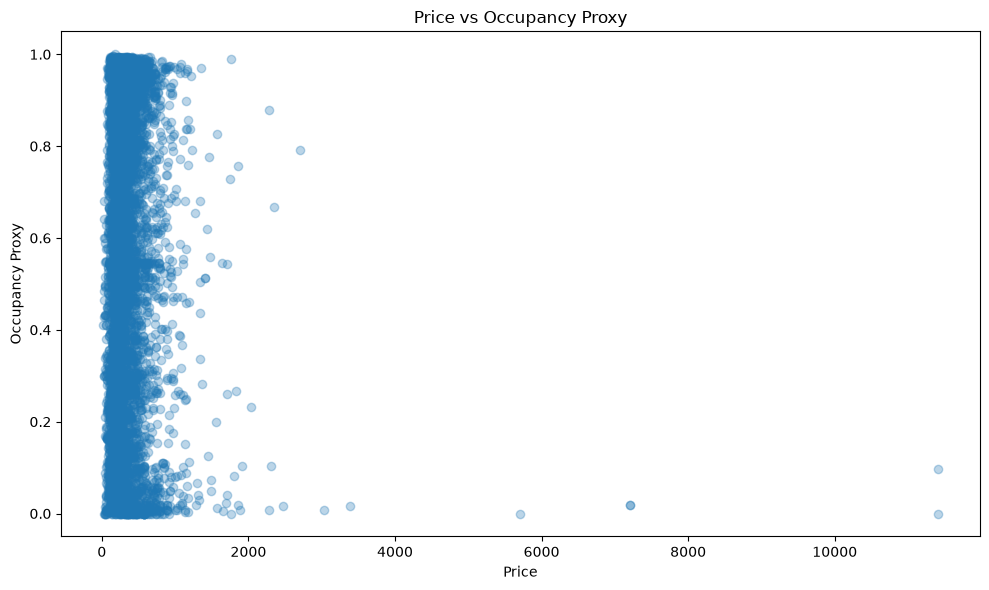

Saved figure to: ..\reports\figures\price_vs_occupancy_proxy_scatter.png


In [53]:
price_occupancy_df = availability_analysis_df[
    availability_analysis_df["price_numeric"].notna() &
    (availability_analysis_df["price_numeric"] > 0)
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    price_occupancy_df["price_numeric"],
    price_occupancy_df["occupancy_proxy"],
    alpha=0.3
)
plt.title("Price vs Occupancy Proxy")
plt.xlabel("Price")
plt.ylabel("Occupancy Proxy")
plt.tight_layout()

output_path = FIGURES_PATH / "price_vs_occupancy_proxy_scatter.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

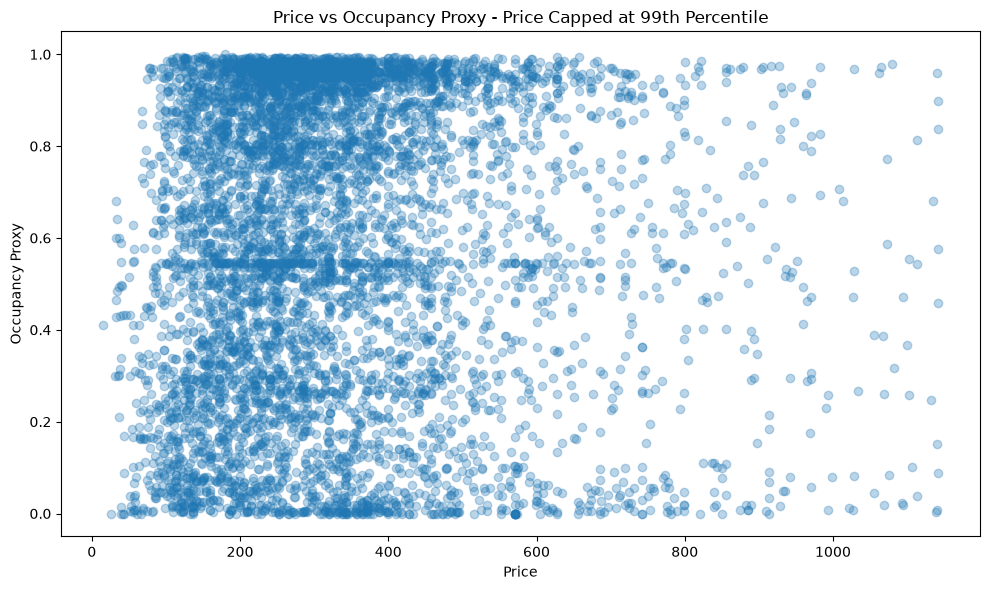

Saved figure to: ..\reports\figures\price_vs_occupancy_proxy_capped_scatter.png


In [54]:
price_99 = price_occupancy_df["price_numeric"].quantile(0.99)

price_occupancy_capped_df = price_occupancy_df[
    price_occupancy_df["price_numeric"] <= price_99
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    price_occupancy_capped_df["price_numeric"],
    price_occupancy_capped_df["occupancy_proxy"],
    alpha=0.3
)
plt.title("Price vs Occupancy Proxy - Price Capped at 99th Percentile")
plt.xlabel("Price")
plt.ylabel("Occupancy Proxy")
plt.tight_layout()

output_path = FIGURES_PATH / "price_vs_occupancy_proxy_capped_scatter.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Business Interpretation

The price versus occupancy proxy scatter plot helps explore whether higher-priced listings are associated with higher or lower unavailable-day ratios.

A capped version is used because extreme price outliers can make the relationship difficult to visually interpret.  
Any relationship observed here should be treated as exploratory and tested statistically before making a final conclusion.

In [55]:
weekend_weekday_summary = pd.DataFrame({
    "metric": ["Weekend Availability Rate", "Weekday Availability Rate"],
    "average_value": [
        availability_analysis_df["weekend_availability_rate"].mean(),
        availability_analysis_df["weekday_availability_rate"].mean()
    ]
})

weekend_weekday_summary["average_value"] = weekend_weekday_summary["average_value"].round(4)

weekend_weekday_summary

,metric,average_value
0,Weekend Availability Rate,0.2599
1,Weekday Availability Rate,0.2621


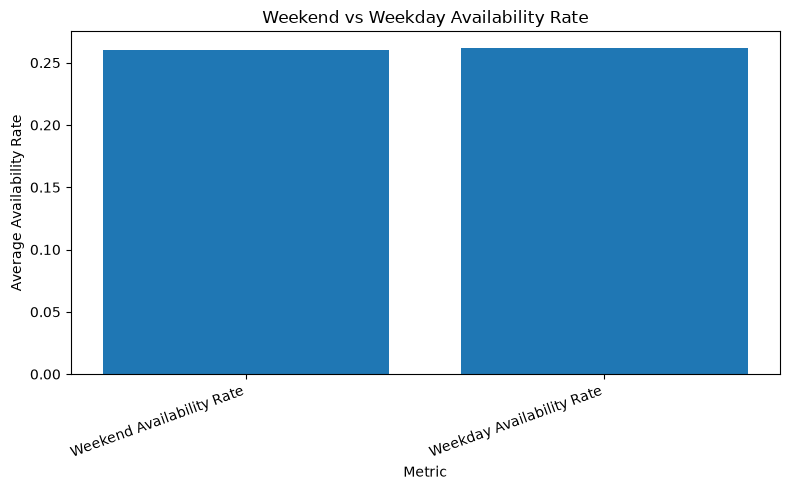

Saved figure to: ..\reports\figures\weekend_vs_weekday_availability_rate.png


In [56]:
plt.figure(figsize=(8, 5))
plt.bar(
    weekend_weekday_summary["metric"],
    weekend_weekday_summary["average_value"]
)
plt.title("Weekend vs Weekday Availability Rate")
plt.xlabel("Metric")
plt.ylabel("Average Availability Rate")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = FIGURES_PATH / "weekend_vs_weekday_availability_rate.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

In [57]:
weekend_weekday_summary_output_path = PROJECT_ROOT / "reports" / "analytics_outputs" / "weekend_weekday_availability_summary.csv"

weekend_weekday_summary.to_csv(weekend_weekday_summary_output_path, index=False)

print(f"Weekend vs weekday summary saved to: {weekend_weekday_summary_output_path}")

Weekend vs weekday summary saved to: ..\reports\analytics_outputs\weekend_weekday_availability_summary.csv


### Business Interpretation

Weekend and weekday availability rates are compared to check whether listings are more restricted during weekends.

If weekend availability is lower, it may suggest stronger weekend demand or more weekend blocking by hosts.  
If the rates are similar, availability behavior may be relatively stable across the week.

### Availability and Occupancy Proxy Summary

Availability analysis confirms that the calendar dataset is useful for measuring availability behavior and occupancy proxy.

However, the occupancy proxy should be interpreted carefully because unavailable days do not necessarily equal booked days.  
This limitation will be clearly stated in the final report.

The availability features created in this project are useful for comparing room types, neighbourhoods, host segments, and review score bands.